In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

***Tarea 1-S2: Modelo de saturación para creciemiento de usuarios.***

Una aplicación móvil nueva comienza a ganar usuarios durante sus primeras semanas. al inicio el crecimiento es rápido, pero conforme pasa el tiempo, el número de usuarios se acerca a un límite máximo debido a que el mercado disponible no es infinito.

Para modelar este comportamiento se propone el siguiente **modelo de saturación**

$$U(t) = L(1-e^{-kt})$$

donde:

*   $U(t)$ es el número de usuarios acumulados en la semana $t$.
*   $L$ es el número máximo esperado de usuarios.
*   $k$ es el parámetro de crecimiento.
*   $t$ es el tiempo medido en semanas.

Supongamos que por estudios previos, se estima que el máximo esperado es $L=10000$.

El modelo queda de la siguiente manera:

$$U(t)=10000(1-e^{-kt})$$}

**Datos observados:**

Se registró el número acumulado de usuarios durante 12 semanas.


In [ ]:
datos ={
    "Semana": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Usuarios_observados": [950, 1800, 2650, 3400, 4100, 4800, 5400, 5900, 6350, 6750, 7100, 7400]
}

df_obs = pd.DataFrame(datos)

df_obs


,Semana,Usuarios_observados
0,1,950
1,2,1800
2,3,2650
3,4,3400
4,5,4100
5,6,4800
6,7,5400
7,8,5900
8,9,6350
9,10,6750


1. Probemos el modelo con un parámetro $k=0.10$

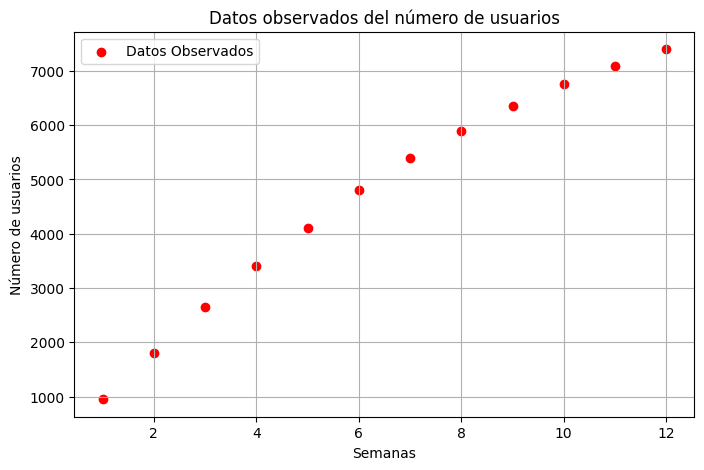

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_obs["Semana"],
    df_obs["Usuarios_observados"],
    label = "Datos Observados",
    color = 'red'
)

plt.xlabel("Semanas")
plt.ylabel("Número de usuarios")
plt.title("Datos observados del número de usuarios")
plt.legend()
plt.grid()

plt.show()

Hagamos una función que nos ayude a simular el modelo:

In [ ]:
def simular_crecimiento(t, k):
    return 10000 * (1 - np.exp(-k*t))

tiempos = np.arange(1, 13,1)

k=0.10

U = simular_crecimiento(tiempos, k)

df_mod = pd.DataFrame({
    "semana": tiempos,
    "usuarios_observados": df_obs["Usuarios_observados"],
    "usuarios_modelo": U
})

df_mod

,semana,usuarios_observados,usuarios_modelo
0,1,950,951.625820
1,2,1800,1812.692469
2,3,2650,2591.817793
3,4,3400,3296.799540
4,5,4100,3934.693403
5,6,4800,4511.883639
6,7,5400,5034.146962
7,8,5900,5506.710359
8,9,6350,5934.303403
9,10,6750,6321.205588


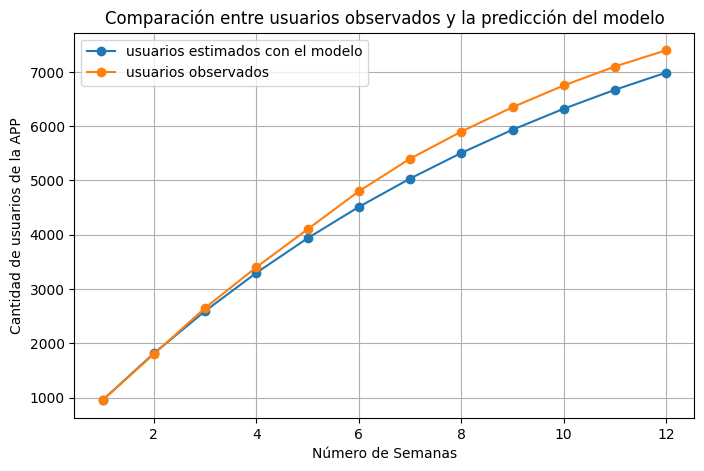

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(tiempos, U, marker="o", label="usuarios estimados con el modelo")
plt.plot(tiempos, df_obs["Usuarios_observados"], marker="o", label="usuarios observados")

plt.xlabel("Número de Semanas")
plt.ylabel("Cantidad de usuarios de la APP")
plt.title("Comparación entre usuarios observados y la predicción del modelo")
plt.grid()
plt.legend()

plt.show()

***Interpretación:*** Visualmente podemos observar que los ususarios estimados y los observados con el modelo crecen rápidamente, teniendo una mayor coincidencia dentro de las primeras 5 semanas. Después de la semana 5, el modelo estima por debajo el número de suarios en comparación con los observados, pero dado a que es poca la diferencia podríamos decir que el modelo, considerando $k=0.10$, si estima bien los datos observados.

***Calculemos ahora las métricas error:***

1.- Error absoluto medio (MAE): $MAE=\dfrac{1}{n}\sum_{i=1}^{n}|y_{i}-\widehat{y}_{i}|$

2.- Error cuadrático medio (MSE): $MSE=\dfrac{1}{n}\sum_{i=1}^{n}(y_{i}-\widehat{y}_{i})^{2}$

3.- Raíz del error cuadrático medio (RMSE): $RMSE= \sqrt{MSE}$.

donde: $y_{i}$ representa los datos observados y $\widehat{y}_{i}$ representa los valores estimados por el modelo.

Antes de resolver este ejercicio, daremos un DataFrame que contenga las columnas de semana, usuarios observados, usuarios del modelo, error, error absoluto y error cuadrático.

In [ ]:
df_errores = pd.DataFrame({
    "semana": tiempos,
    "usuarios_observados": df_obs["Usuarios_observados"],
    "usuarios_modelo": U,
    "error": np.abs(df_mod["usuarios_observados"]-df_mod["usuarios_modelo"]),

})

df_errores["error_absoluto"] = np.abs(df_errores["error"])
df_errores["error_cuadratico"] = df_errores["error"]**2

df_errores

,semana,usuarios_observados,usuarios_modelo,error,error_absoluto,error_cuadratico
0,1,950,951.625820,1.625820,1.625820,2.643290
1,2,1800,1812.692469,12.692469,12.692469,161.098775
2,3,2650,2591.817793,58.182207,58.182207,3385.169190
3,4,3400,3296.799540,103.200460,103.200460,10650.335018
4,5,4100,3934.693403,165.306597,165.306597,27326.271053
5,6,4800,4511.883639,288.116361,288.116361,83011.037441
6,7,5400,5034.146962,365.853038,365.853038,133848.445351
7,8,5900,5506.710359,393.289641,393.289641,154676.741853
8,9,6350,5934.303403,415.696597,415.696597,172803.661095
9,10,6750,6321.205588,428.794412,428.794412,183864.647518


In [ ]:
mae = df_errores["error_absoluto"].mean()
mse = df_errores["error_cuadratico"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 256.11754653419126
MSE: 93601.6118196282
RMSE: 305.9438050028603


1. ¿Cuál es el MAE del modelo? Sol: El error absoluto medio del modelo tiene un valor de aproximadamente 256.1175 lo que significa que en promedio esa es la diferencia entre los valores reales reportados y los dados por el modelo.

2. ¿Cuál es el MSE? Sol: El error cuadrático medio MSE tiene un valor aproximado de 93601.6118. Al ser un valor grande nos puede indicar que hubo errores grandes en alguna de las observaciones.

3. ¿Cuál es el RMSE? Sol: La raíz cuadrada del error cuadrático medio RMSE tiene un valor aproximado de 305.9438, al ser mayor que el MAE sugiere que hubo una desviación un poco mayor en ciertas semanas, que hacen que el promedio cuadrático sea más grande.

4. ¿El error es grande o pequeño en comparción con el número de usuarios? Sol: El error no es excesivamente grande en comparación con el número total de usuarios. Un RMSE de aproximadamente 306 usuarios frente a valores de hasta 7400 usuarios indica que el modelo da una aproximación razonable, aunque todavía puede mejorarse ajustando mejor el parámetro $k$.

***Ahora probemos varios valores posibles para $k$***

Consideremos $k$ en el siguiente conjunto de valores:
$$\{0.05, 0.06, 0.07, \dots, 0.20\}$$

In [ ]:
def usuarios(t, k):
    return 10000 * (1 - np.exp(-k*t))

tiempos = np.arange(1, 13, 1)
valores_k = np.arange(0.05, 0.21, 0.01)

datos = {"semana": tiempos} #diccionario inicial con la columna tiempo

for k in valores_k:
  datos[f"k={k:.4f}"] = usuarios(tiempos,k)


df = pd.DataFrame(datos)

df

,semana,k=0.0500,k=0.0600,k=0.0700,k=0.0800,k=0.0900,k=0.1000,k=0.1100,k=0.1200,k=0.1300,k=0.1400,k=0.1500,k=0.1600,k=0.1700,k=0.1800,k=0.1900,k=0.2000
0,1,487.705755,582.354664,676.061801,768.836536,860.688147,951.625820,1041.658647,1130.795633,1219.045691,1306.417646,1392.920236,1478.562110,1563.351834,1647.297886,1730.408661,1812.692469
1,2,951.625820,1130.795633,1306.417646,1478.562110,1647.297886,1812.692469,1974.812020,2133.721389,2289.484142,2442.162585,2591.817793,2738.509629,2882.296772,3023.236739,3161.385908,3296.799540
2,3,1392.920236,1647.297886,1894.157540,2133.721389,2366.205057,2591.817793,2810.762666,3023.236739,3229.431255,3429.531802,3623.718484,3812.166082,3995.044212,4172.517476,4344.745613,4511.883639
3,4,1812.692469,2133.721389,2442.162585,2738.509629,3023.236739,3296.799540,3559.635789,3812.166082,4054.794520,4287.909362,4511.883639,4727.075760,4933.830076,5132.477440,5323.335730,5506.710359
4,5,2211.992169,2591.817793,2953.119103,3296.799540,3623.718484,3934.693403,4230.501896,4511.883639,4779.542232,5034.146962,5276.334473,5506.710359,5725.850681,5934.303403,6132.589765,6321.205588
5,6,2591.817793,3023.236739,3429.531802,3812.166082,4172.517476,4511.883639,4831.486655,5132.477440,5415.939887,5682.894766,5934.303403,6171.071140,6394.050598,6604.044744,6801.809782,6988.057881
6,7,2953.119103,3429.531802,3873.736058,4287.909362,4674.081990,5034.146962,5369.869317,5682.894766,5974.757760,6246.889011,6500.622509,6737.202054,6957.787359,7163.459735,7355.227387,7534.030361
7,8,3296.799540,3812.166082,4287.909362,4727.075760,5132.477440,5506.710359,5852.170883,6171.071140,6465.453180,6737.202054,6988.057881,7219.626995,7433.392230,7630.722413,7812.881130,7981.034820
8,9,3623.718484,4172.517476,4674.081990,5132.477440,5551.419338,5934.303403,6284.233090,6604.044744,6896.330587,7163.459735,7407.597394,7630.722413,7834.643327,8021.013009,8191.342074,8347.011118
9,10,3934.693403,4511.883639,5034.146962,5506.710359,5934.303403,6321.205588,6671.289163,6988.057881,7274.682070,7534.030361,7768.698399,7981.034820,8173.164759,8347.011118,8504.313808,8646.647168


In [ ]:
def simular_crecimiento(t, k):
    return 10000 * (1 - np.exp(-k*t))


tiempos = np.arange(1, 13, 1)
valores_k = np.arange(0.05, 0.21, 0.01)

resultados = []

for k in valores_k:

  usuarios_modelo = simular_crecimiento(tiempos, k)

  df_modelo = pd.DataFrame({
      "Semana": tiempos,
      "usuarios_modelo": usuarios_modelo
  })

  df_comparacion = pd.merge(df_obs, df_modelo, on="Semana")

  error = (
      df_comparacion["Usuarios_observados"]
      -df_comparacion["usuarios_modelo"]
  )

  mae = np.mean(np.abs(error))
  mse = np.mean(error**2)
  rmse = np.sqrt(mse)

  resultados.append({
      "k": k,
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse
  })

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.05,2050.044141,4.847631e+06,2201.733561
1,0.06,1633.392733,3.075298e+06,1753.652702
2,0.07,1247.992589,1.801992e+06,1342.383084
3,0.08,891.165814,9.307644e+05,964.761339
4,0.09,560.481351,3.827103e+05,618.635820
5,0.10,256.117547,9.360161e+04,305.943805
6,0.11,93.718420,1.115316e+04,105.608507
7,0.12,295.809904,9.280538e+04,304.639749
8,0.13,542.084283,3.039240e+05,551.293039
9,0.14,771.424459,6.163369e+05,785.071252


Encontremos el menor valor de $k$ que produce el menor RMSE

In [ ]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("El mejor valor encontrado:")
print(mejor)

El mejor valor encontrado:
k           0.110000
MAE        93.718420
MSE     11153.156792
RMSE      105.608507
Name: 6, dtype: float64


In [ ]:
k_mejor = mejor["k"]

print(f"k óptimo aproximado: {k_mejor:.2f}")

k óptimo aproximado: 0.11


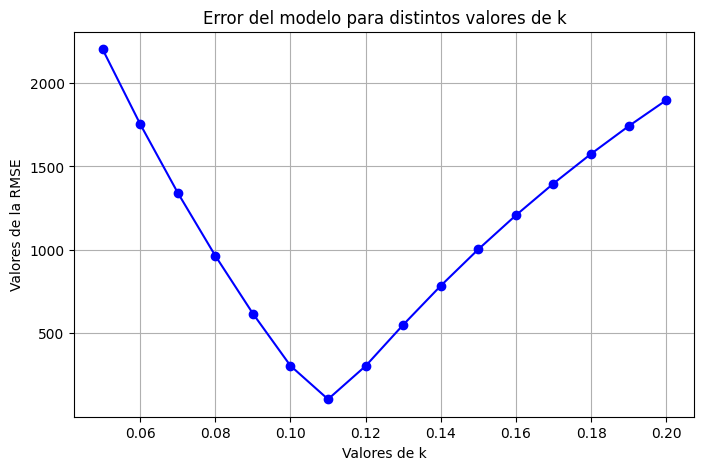

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(df_resultados["k"], df_resultados["RMSE"], marker="o", color='blue')

plt.xlabel("Valores de k")
plt.ylabel("Valores de la RMSE")
plt.title("Error del modelo para distintos valores de k")
plt.grid()
plt.show()

1. ¿Cuál es el mejor valor de $k$? Sol: El mejor valor de $k$ es el que minimiza el RMSE, ya que esta fue la métrica usada para comparar los ajustes del modelo. En este caso, el valor óptimo fue $k=0.11$.

2. ¿Cuál es el menor RMSE obtenido? Sol: El menor valor obtenido para la RMSE fue de 105.6085.

3. ¿Qué significa que un valor de $k$ tenga menor RMSE que otro? Sol: Que un valor de $k$ tenga menor RMSE significa que las predicciones del modelo están, en promedio, más cerca de los datos observados. Por lo tanto, ese parámetro describe mejor el comportamiento real del crecimiento de usuarios.

4. ¿El modelo mejora respecto al caso inicial $k=0.10$? Sol: Si, el modelo mejora bastante pues con $k=0.10$ teníamos un MAE: 256.1175, un MSE: 93601.61181 y un RMSE: 305.94380, en cambio con $k=0.11$ tenemos MAE: 93.718420, un MSE: 11153.156792 y un RMSE: 105.608507. Es decir con $k=0.11$ tenemos un mejor ajuste, esto es, hay menor error entre los datos observados y los datos modelados.

In [ ]:
def simular_crecimiento(t, k):
    return 10000 * (1 - np.exp(-k*t))

tiempos = np.arange(1, 13,1)

k=0.11

U_2 = simular_crecimiento(tiempos, k)

df_mod = pd.DataFrame({
    "semana": tiempos,
    "usuarios_observados": df_obs["Usuarios_observados"],
    "usuarios_modelo": U_2
})

df_mod

,semana,usuarios_observados,usuarios_modelo
0,1,950,1041.658647
1,2,1800,1974.812020
2,3,2650,2810.762666
3,4,3400,3559.635789
4,5,4100,4230.501896
5,6,4800,4831.486655
6,7,5400,5369.869317
7,8,5900,5852.170883
8,9,6350,6284.233090
9,10,6750,6671.289163


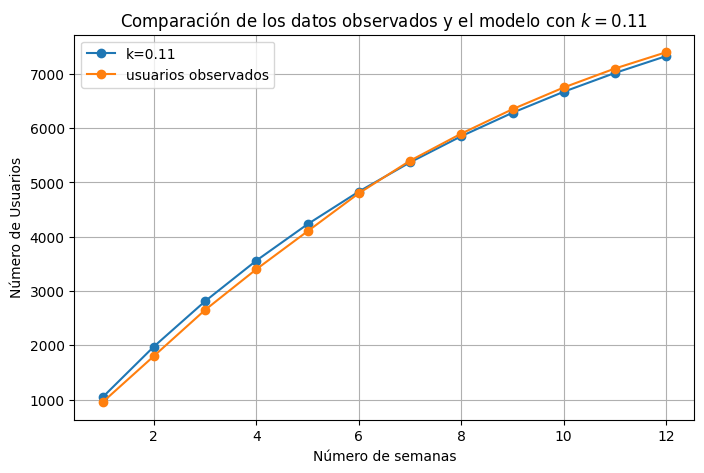

In [ ]:
plt.figure(figsize=(8,5))

#plt.plot(tiempos, U, marker="o", label="k=0.10")
plt.plot(tiempos, U_2, marker="o", label="k=0.11")
plt.plot(tiempos, df_obs["Usuarios_observados"], marker="o", label="usuarios observados")

plt.xlabel("Número de semanas")
plt.ylabel("Número de Usuarios")
plt.title("Comparación de los datos observados y el modelo con $k=0.11$")
plt.grid()
plt.legend()

plt.show()

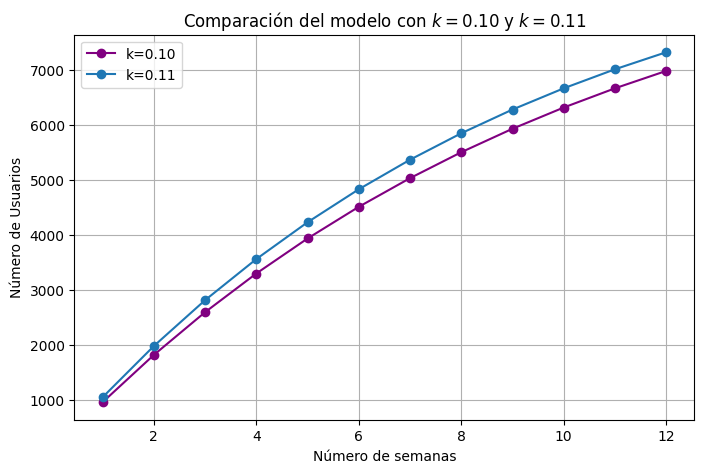

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(tiempos, U, marker="o", label="k=0.10", color='purple')
plt.plot(tiempos, U_2, marker="o", label="k=0.11")
#plt.plot(tiempos, df_obs["Usuarios_observados"], marker="o", label="usuarios observados")

plt.xlabel("Número de semanas")
plt.ylabel("Número de Usuarios")
plt.title("Comparación del modelo con $k=0.10$ y $k=0.11$")
plt.grid()
plt.legend()

plt.show()

1. ¿El modelo ajustado sigue mejor la tendencia de los datos? Sol: Si, el modelo ajustado sigue mejor la tendencia de los datos, podemos observarlo en la gráfica y en los datos obtenidos de MAE, MSE y RMSE, pues el error absoluto medio y la RMSe es menor con $k=0.11$ que con cualquier otro valor de $k$.

2. ¿En qué semanas se observa mayor diferencia entre los datos y el modelo? Sol: La mayor diferencia se observa en las últimas semanas, especialmente alrededor de la semana 11, donde el modelo se separa más de los datos observados.

3. ¿Crees que el modelo es razonable para describir el crecimiento de los usuarios? Sol: Si, siempre y cuando consideremos $k=0.11$, pues en ese caso el error absoluto medio y la raíz del error cuadrático medio son menores que en cualquier otro caso.

***Entrenamiento y prueba***

Los datos de entrenamiento serán de las semanas 1 a 8, y los datos de prueba serán de las semanas 9 a 12.

In [ ]:
df_train = df_obs[df_obs["Semana"] <= 8].copy()
df_test = df_obs[df_obs["Semana"] > 8].copy()

print("Datos de entrenamiento")
print(df_train)

print("Datos de prueba")
print(df_test)

Datos de entrenamiento
   Semana  Usuarios_observados
0       1                  950
1       2                 1800
2       3                 2650
3       4                 3400
4       5                 4100
5       6                 4800
6       7                 5400
7       8                 5900
Datos de prueba
    Semana  Usuarios_observados
8        9                 6350
9       10                 6750
10      11                 7100
11      12                 7400


In [ ]:
resultados_train = []

for k in valores_k:
  usuarios_modelo = simular_crecimiento(tiempos, k)

  df_mod = pd.DataFrame({
        "Semana": tiempos,
        "usuarios_modelo": usuarios_modelo
    })

  df_comparacion = pd.merge(df_train, df_mod, on="Semana")

  error = (
      df_comparacion["Usuarios_observados"]
      -df_comparacion["usuarios_modelo"]
  )

  rmse = np.sqrt(np.mean(error**2))

  resultados_train.append({
      "k": k,
      "RMSE_train": rmse
  })

df_resultados_train = pd.DataFrame(resultados_train)

mejor_train = df_resultados_train.loc[df_resultados_train["RMSE_train"].idxmin()]

k_train = mejor_train["k"]

print(f"Mejor k usando en el entrenamiento: {k_train:.2f}")


Mejor k usando en el entrenamiento: 0.11


In [ ]:
def usuarios(t, k):
    return 10000 * (1 - np.exp(-k*t))

tiempos = np.arange(1, 9, 1)
valores_k = np.arange(0.05, 0.21, 0.01)

datos = {"semana": tiempos} #diccionario inicial con la columna tiempo

for k in valores_k:
  datos[f"k={k:.4f}"] = usuarios(tiempos,k)


df = pd.DataFrame(datos)

df

,semana,k=0.0500,k=0.0600,k=0.0700,k=0.0800,k=0.0900,k=0.1000,k=0.1100,k=0.1200,k=0.1300,k=0.1400,k=0.1500,k=0.1600,k=0.1700,k=0.1800,k=0.1900,k=0.2000
0,1,487.705755,582.354664,676.061801,768.836536,860.688147,951.625820,1041.658647,1130.795633,1219.045691,1306.417646,1392.920236,1478.562110,1563.351834,1647.297886,1730.408661,1812.692469
1,2,951.625820,1130.795633,1306.417646,1478.562110,1647.297886,1812.692469,1974.812020,2133.721389,2289.484142,2442.162585,2591.817793,2738.509629,2882.296772,3023.236739,3161.385908,3296.799540
2,3,1392.920236,1647.297886,1894.157540,2133.721389,2366.205057,2591.817793,2810.762666,3023.236739,3229.431255,3429.531802,3623.718484,3812.166082,3995.044212,4172.517476,4344.745613,4511.883639
3,4,1812.692469,2133.721389,2442.162585,2738.509629,3023.236739,3296.799540,3559.635789,3812.166082,4054.794520,4287.909362,4511.883639,4727.075760,4933.830076,5132.477440,5323.335730,5506.710359
4,5,2211.992169,2591.817793,2953.119103,3296.799540,3623.718484,3934.693403,4230.501896,4511.883639,4779.542232,5034.146962,5276.334473,5506.710359,5725.850681,5934.303403,6132.589765,6321.205588
5,6,2591.817793,3023.236739,3429.531802,3812.166082,4172.517476,4511.883639,4831.486655,5132.477440,5415.939887,5682.894766,5934.303403,6171.071140,6394.050598,6604.044744,6801.809782,6988.057881
6,7,2953.119103,3429.531802,3873.736058,4287.909362,4674.081990,5034.146962,5369.869317,5682.894766,5974.757760,6246.889011,6500.622509,6737.202054,6957.787359,7163.459735,7355.227387,7534.030361
7,8,3296.799540,3812.166082,4287.909362,4727.075760,5132.477440,5506.710359,5852.170883,6171.071140,6465.453180,6737.202054,6988.057881,7219.626995,7433.392230,7630.722413,7812.881130,7981.034820


Cálculo de la RMSE para cada valor de k.

In [ ]:
df_train = df_obs[df_obs["Semana"] <= 8] #Datos de entrenamiento.

resultados_rmse = []

for k in valores_k:

    # Valores del modelo
    usuarios_modelo = usuarios(tiempos, k)

    # DataFrame del modelo
    df_modelo = pd.DataFrame({
        "Semana": tiempos,
        "usuarios_modelo": usuarios_modelo
    })

    # Unir datos observados y modelo
    df_comparacion = pd.merge(df_train, df_modelo, on="Semana")


    error = (
        df_comparacion["Usuarios_observados"]
        - df_comparacion["usuarios_modelo"]
    )


    rmse = np.sqrt(np.mean(error**2))

    resultados_rmse.append({
        "k": k,
        "RMSE": rmse
    })

df_rmse = pd.DataFrame(resultados_rmse)

df_rmse

,k,RMSE
0,0.05,1811.000084
1,0.06,1451.945560
2,0.07,1114.072077
3,0.08,796.374545
4,0.09,498.799923
5,0.10,227.228338
6,0.11,118.060581
7,0.12,332.968084
8,0.13,566.537744
9,0.14,791.021585


Encontremos el mejor parámetro $k_{mejor}$.

In [ ]:
simulado_k = df_rmse.loc[df_rmse["RMSE"].idxmin()]

k_mejor = simulado_k["k"]

print(f"El mejor k sobre todos los RMSE es: {k_mejor:.2f}")

El mejor k sobre todos los RMSE es: 0.11


In [ ]:
def simular_crecimiento(t, k):
    return 10000 * (1 - np.exp(-k*t))

tiempos = np.arange(9, 13, 1)

k = 0.11

U_2 = simular_crecimiento(tiempos, k)

# DataFrame del modelo
df_prueba = pd.DataFrame({
    "Semana": tiempos,
    "usuarios_modelo": U_2
})

# Datos observados de prueba (semanas 9 a 12)
df_obs_prueba = df_obs[df_obs["Semana"] > 8]

# Unir ambos DataFrames
df_prueba = pd.merge(df_obs_prueba, df_prueba, on="Semana")

df_prueba

,Semana,Usuarios_observados,usuarios_modelo
0,9,6350,6284.233090
1,10,6750,6671.289163
2,11,7100,7018.027206
3,12,7400,7328.646980


In [ ]:
df_errores_prueba = pd.DataFrame({
    "semana": df_prueba["Semana"],
    "usuarios_observados": df_prueba["Usuarios_observados"],
    "usuarios_modelo": df_prueba["usuarios_modelo"],
    "error": np.abs(df_prueba["Usuarios_observados"]-df_prueba["usuarios_modelo"])
})

df_errores_prueba["error_absoluto"] = np.abs(df_errores_prueba["error"])
df_errores_prueba["error_cuadratico"] = df_errores_prueba["error"]**2

df_errores_prueba

,semana,usuarios_observados,usuarios_modelo,error,error_absoluto,error_cuadratico
0,9,6350,6284.233090,65.766910,65.766910,4325.286480
1,10,6750,6671.289163,78.710837,78.710837,6195.395858
2,11,7100,7018.027206,81.972794,81.972794,6719.539005
3,12,7400,7328.646980,71.353020,71.353020,5091.253414


In [ ]:
mae = df_errores_prueba["error_absoluto"].mean()
mse = df_errores_prueba["error_cuadratico"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 74.45089028965731
MSE: 5582.868689428797
RMSE: 74.71859667732522


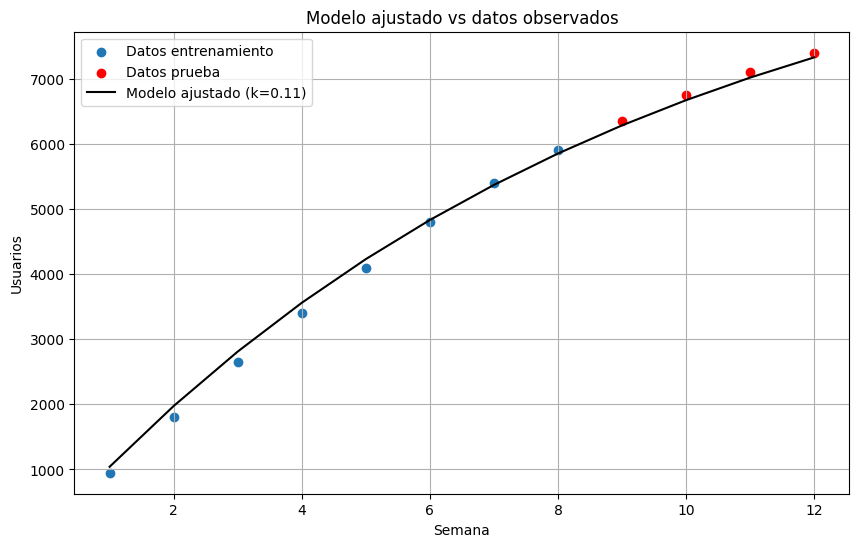

In [ ]:

# Valor óptimo de k
k = 0.11

# Tiempo completo
tiempos_modelo = np.arange(1, 13, 1)

# Valores del modelo
usuarios_modelo = simular_crecimiento(tiempos_modelo, k)

# Datos de entrenamiento
df_train = df_obs[df_obs["Semana"] <= 8]

# Datos de prueba
df_test = df_obs[df_obs["Semana"] >= 9]

# Gráfica
plt.figure(figsize=(10,6))

# Datos observados de entrenamiento
plt.scatter(
    df_train["Semana"],
    df_train["Usuarios_observados"],
    label="Datos entrenamiento"
)

# Datos observados de prueba
plt.scatter(
    df_test["Semana"],
    df_test["Usuarios_observados"],
    label="Datos prueba",
    color='red'
)

# Modelo ajustado
plt.plot(
    tiempos_modelo,
    usuarios_modelo,
    label="Modelo ajustado (k=0.11)",
    color='black'
)

# Etiquetas y formato
plt.xlabel("Semana")
plt.ylabel("Usuarios")
plt.title("Modelo ajustado vs datos observados")
plt.legend()
plt.grid()

plt.show()

***Preguntas finales:***

1. ¿Cuál fue el mejor valor de $k$ usando solamente los datos de entrenamiento? Sol: De acuerdo a los datos, el mejor valor de $k$ nuevamente es $k=0.11$.

2. ¿Cuál fue el RMSE de entrenamiento? Sol: El RMSE fue de 118.0605.

3. ¿Cuál fue el RMSE en prueba? Sol: El RMSE en los valores de prueba fue de 74.7185.

4. ¿El modelo generaliza bien a las semanas que no se usaron para ajustar el parámetro? Sol: Sí, el modelo generaliza bien a las semanas que no se usaron para ajustar el parámetro, ya que el RMSE en prueba fue incluso menor que el RMSE en entrenamiento, lo cual indica que el modelo mantiene un buen ajuste para datos no utilizados.

5. ¿Qué diferencia hay entre ajustar el parámetro usando todos los datos y ajustarlo usando solo entrenamiento? Sol: Cuando se ajusta el parámetro usando todos los datos, el modelo utiliza toda la información disponible, incluyendo los datos que después podrían usarse para evaluar su desempeño. Esto puede dar una estimación más ajustada a ese conjunto particular, pero no permite medir qué tan bien predice datos nuevos.
En cambio, ajustar usando solo los datos de entrenamiento significa que el parámetro k se calcula sin conocer los datos de prueba. Esto permite evaluar de manera más realista si el modelo puede generalizar y hacer buenas predicciones en semanas que no se usaron para calibrarlo.

6. ¿Por qué es importante separar datos de entrenamiento y prueba? Sol: Separar los datos en entrenamiento y prueba es importante porque permite evaluar la capacidad de generalización del modelo. Si solo se ajusta y evalúa con los mismos datos, el modelo puede parecer muy preciso, pero eso no garantiza que funcione bien con datos nuevos.
El conjunto de entrenamiento se usa para ajustar los parámetros del modelo, mientras que el conjunto de prueba sirve para verificar si ese ajuste realmente describe el fenómeno y puede predecir observaciones futuras. Esta separación evita conclusiones engañosas sobre la calidad del modelo.